# 05 - Análisis logístico

## 1. Objetivo del notebook

Este notebook busca entender la eficiencia logística del marketplace Olist, midiendo tiempos de entrega, retrasos, cumplimiento frente a la promesa de entrega y posibles factores asociados a malas experiencias.

El análisis incluye:
- Tiempos de aprobación, despacho y entrega
- Retrasos frente a la fecha estimada
- Entregas tardías vs. puntuales
- Comportamiento por estado, categoría y vendedor
- Distancia aproximada entre cliente y vendedor
- Impacto logístico en la satisfacción del cliente

## 2. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import math

# Configurar pandas para mostrar más columnas
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

## 3. Configuración de rutas

In [2]:
# Definir rutas con pathlib
ROOT_DIR = Path.cwd().parent
DATA_RAW_DIR = ROOT_DIR / 'data' / 'raw'
DATA_PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
REPORTS_DIR = ROOT_DIR / 'reports'
FIGURES_DIR = ROOT_DIR / 'reports' / 'figures'

# Crear directorios si no existen
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT_DIR: {ROOT_DIR}")
print(f"DATA_RAW_DIR: {DATA_RAW_DIR}")
print(f"DATA_PROCESSED_DIR: {DATA_PROCESSED_DIR}")
print(f"REPORTS_DIR: {REPORTS_DIR}")
print(f"FIGURES_DIR: {FIGURES_DIR}")

ROOT_DIR: c:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence
DATA_RAW_DIR: c:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\data\raw
DATA_PROCESSED_DIR: c:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\data\processed
REPORTS_DIR: c:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\reports
FIGURES_DIR: c:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\reports\figures


## 4. Carga de datos

In [3]:
# Cargar datos procesados
fact_orders = pd.read_csv(DATA_PROCESSED_DIR / 'fact_orders.csv')
dim_geolocation_zip = pd.read_csv(DATA_PROCESSED_DIR / 'dim_geolocation_zip.csv')
dim_sellers = pd.read_csv(DATA_PROCESSED_DIR / 'dim_sellers.csv')
dim_customers = pd.read_csv(DATA_PROCESSED_DIR / 'dim_customers.csv')
dim_products = pd.read_csv(DATA_PROCESSED_DIR / 'dim_products.csv')

# Cargar datos crudos adicionales necesarios
order_items = pd.read_csv(DATA_RAW_DIR / 'olist_order_items_dataset.csv')

# Convertir a datetime en fact_orders
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in datetime_cols:
    fact_orders[col] = pd.to_datetime(fact_orders[col], errors='coerce')

# Mostrar shape de cada tabla
print("Shape de tablas cargadas:")
print(f"fact_orders: {fact_orders.shape}")
print(f"dim_geolocation_zip: {dim_geolocation_zip.shape}")
print(f"dim_sellers: {dim_sellers.shape}")
print(f"dim_customers: {dim_customers.shape}")
print(f"dim_products: {dim_products.shape}")
print(f"order_items: {order_items.shape}")

Shape de tablas cargadas:
fact_orders: (99441, 51)
dim_geolocation_zip: (19015, 5)
dim_sellers: (3095, 4)
dim_customers: (99441, 5)
dim_products: (32951, 10)
order_items: (112650, 7)


## 5. Validación inicial de variables logísticas

In [4]:
# Validar existencia de variables logísticas en fact_orders
logistic_vars = [
    'approval_time_days',
    'carrier_handling_time_days',
    'delivery_time_days',
    'estimated_delivery_time_days',
    'delivery_delay_days',
    'is_late',
    'is_delivered',
    'order_status',
    'customer_state',
    'main_category',
    'review_score_avg',
    'bad_review',
    'total_price',
    'total_freight',
    'freight_ratio'
]

print("Validación de variables logísticas:")
for var in logistic_vars:
    exists = var in fact_orders.columns
    print(f"  {var}: {'✓' if exists else '✗'}")

# Mostrar estadísticas iniciales
total_orders = len(fact_orders)
delivered_orders = fact_orders['is_delivered'].sum() if 'is_delivered' in fact_orders.columns else 0
not_delivered_orders = total_orders - delivered_orders
late_orders = fact_orders['is_late'].sum() if 'is_late' in fact_orders.columns else 0
late_rate = (late_orders / delivered_orders * 100) if delivered_orders > 0 else 0

purchase_date_min = fact_orders['order_purchase_timestamp'].min()
purchase_date_max = fact_orders['order_purchase_timestamp'].max()

print(f"\nEstadísticas iniciales:")
print(f"  Total de órdenes: {total_orders:,}")
print(f"  Órdenes entregadas: {delivered_orders:,}")
print(f"  Órdenes no entregadas: {not_delivered_orders:,}")
print(f"  Órdenes tardías: {late_orders:,}")
print(f"  Porcentaje de órdenes tardías: {late_rate:.2f}%")
print(f"  Rango de fechas de compra: {purchase_date_min} a {purchase_date_max}")

Validación de variables logísticas:
  approval_time_days: ✓
  carrier_handling_time_days: ✓
  delivery_time_days: ✓
  estimated_delivery_time_days: ✓
  delivery_delay_days: ✓
  is_late: ✓
  is_delivered: ✓
  order_status: ✓
  customer_state: ✓
  main_category: ✓
  review_score_avg: ✓
  bad_review: ✓
  total_price: ✓
  total_freight: ✓
  freight_ratio: ✓

Estadísticas iniciales:
  Total de órdenes: 99,441
  Órdenes entregadas: 96,476
  Órdenes no entregadas: 2,965
  Órdenes tardías: 7,827.0
  Porcentaje de órdenes tardías: 8.11%
  Rango de fechas de compra: 2016-09-04 21:15:19 a 2018-10-17 17:30:18


## 6. Universo de análisis logístico

In [5]:
# Crear dataframe logistics_base usando principalmente órdenes entregadas
logistics_base = fact_orders[
    (fact_orders['is_delivered'] == 1) &
    (fact_orders['order_delivered_customer_date'].notna()) &
    (fact_orders['order_purchase_timestamp'].notna()) &
    (fact_orders['order_estimated_delivery_date'].notna())
].copy()

# Mostrar estadísticas del universo de análisis
total_logistics = len(logistics_base)
pct_logistics = (total_logistics / total_orders * 100) if total_orders > 0 else 0
logistics_purchase_min = logistics_base['order_purchase_timestamp'].min()
logistics_purchase_max = logistics_base['order_purchase_timestamp'].max()
logistics_delivery_min = logistics_base['order_delivered_customer_date'].min()
logistics_delivery_max = logistics_base['order_delivered_customer_date'].max()

print(f"Universo de análisis logístico:")
print(f"  Filas en logistics_base: {total_logistics:,}")
print(f"  Porcentaje frente al total de órdenes: {pct_logistics:.2f}%")
print(f"  Rango de fechas de compra: {logistics_purchase_min} a {logistics_purchase_max}")
print(f"  Rango de fechas de entrega: {logistics_delivery_min} a {logistics_delivery_max}")

Universo de análisis logístico:
  Filas en logistics_base: 96,476
  Porcentaje frente al total de órdenes: 97.02%
  Rango de fechas de compra: 2016-09-15 12:16:38 a 2018-08-29 15:00:37
  Rango de fechas de entrega: 2016-10-11 13:46:32 a 2018-10-17 13:22:46


**Nota:** El análisis logístico principal se hace sobre órdenes entregadas, porque las órdenes no entregadas no tienen fecha real de entrega al cliente, lo que impide calcular tiempos de entrega y retrasos reales.

## 7. KPIs logísticos generales

In [6]:
# Calcular tabla logistics_kpi_summary
logistics_kpi_summary = pd.DataFrame([{
    'total_delivered_orders': len(logistics_base),
    'avg_approval_time_days': logistics_base['approval_time_days'].mean(),
    'median_approval_time_days': logistics_base['approval_time_days'].median(),
    'avg_carrier_handling_time_days': logistics_base['carrier_handling_time_days'].mean(),
    'median_carrier_handling_time_days': logistics_base['carrier_handling_time_days'].median(),
    'avg_delivery_time_days': logistics_base['delivery_time_days'].mean(),
    'median_delivery_time_days': logistics_base['delivery_time_days'].median(),
    'avg_estimated_delivery_time_days': logistics_base['estimated_delivery_time_days'].mean(),
    'median_estimated_delivery_time_days': logistics_base['estimated_delivery_time_days'].median(),
    'avg_delivery_delay_days': logistics_base['delivery_delay_days'].mean(),
    'median_delivery_delay_days': logistics_base['delivery_delay_days'].median(),
    'late_delivery_rate': (logistics_base['is_late'].sum() / len(logistics_base) * 100),
    'early_or_on_time_rate': ((logistics_base['delivery_delay_days'] <= 0).sum() / len(logistics_base) * 100),
    'avg_freight_value': logistics_base['total_freight'].mean(),
    'avg_freight_ratio': logistics_base['freight_ratio'].mean(),
    'avg_review_score_delivered': logistics_base['review_score_avg'].mean(),
    'bad_review_rate_delivered': (logistics_base['bad_review'].sum() / len(logistics_base) * 100)
}])

# Guardar en reports
logistics_kpi_summary.to_csv(REPORTS_DIR / 'logistics_kpi_summary.csv', index=False)

print("KPIs logísticos generales:")
display(logistics_kpi_summary.T)

KPIs logísticos generales:


,0
total_delivered_orders,96476.000000
avg_approval_time_days,0.428235
median_approval_time_days,0.014306
avg_carrier_handling_time_days,2.799283
median_carrier_handling_time_days,1.815856
avg_delivery_time_days,12.558702
median_delivery_time_days,10.217755
avg_estimated_delivery_time_days,23.737822
median_estimated_delivery_time_days,23.231343
avg_delivery_delay_days,-11.179120


## 8. Distribución de tiempos logísticos

In [7]:
# Crear tablas descriptivas de tiempos logísticos
time_vars = ['approval_time_days', 'carrier_handling_time_days', 'delivery_time_days', 
             'estimated_delivery_time_days', 'delivery_delay_days']

logistics_time_distribution = pd.DataFrame()
for var in time_vars:
    var_data = logistics_base[var].dropna()
    logistics_time_distribution[var] = [
        var_data.mean(),
        var_data.median(),
        var_data.quantile(0.25),
        var_data.quantile(0.75),
        var_data.quantile(0.90),
        var_data.quantile(0.95),
        var_data.quantile(0.99),
        var_data.min(),
        var_data.max()
    ]

logistics_time_distribution.index = ['mean', 'median', 'p25', 'p75', 'p90', 'p95', 'p99', 'min', 'max']

# Guardar en reports
logistics_time_distribution.to_csv(REPORTS_DIR / 'logistics_time_distribution.csv')

print("Distribución de tiempos logísticos:")
display(logistics_time_distribution)

Distribución de tiempos logísticos:


,approval_time_days,carrier_handling_time_days,delivery_time_days,estimated_delivery_time_days,delivery_delay_days
mean,0.428235,2.799283,12.558702,23.737822,-11.179120
median,0.014306,1.815856,10.217755,23.231343,-11.948941
p25,0.008970,0.874363,6.766403,18.330014,-16.244384
p75,0.604905,3.575208,15.720327,28.408371,-6.390000
p90,1.441387,5.990532,23.097604,34.288015,-1.137517
p95,2.010958,8.086551,29.276016,38.420859,3.818458
p99,3.741088,17.067164,46.049913,50.243950,18.939306
min,0.000000,-171.219005,0.533414,2.008009,-146.016123
max,30.893484,125.762569,209.628611,155.135463,188.975081


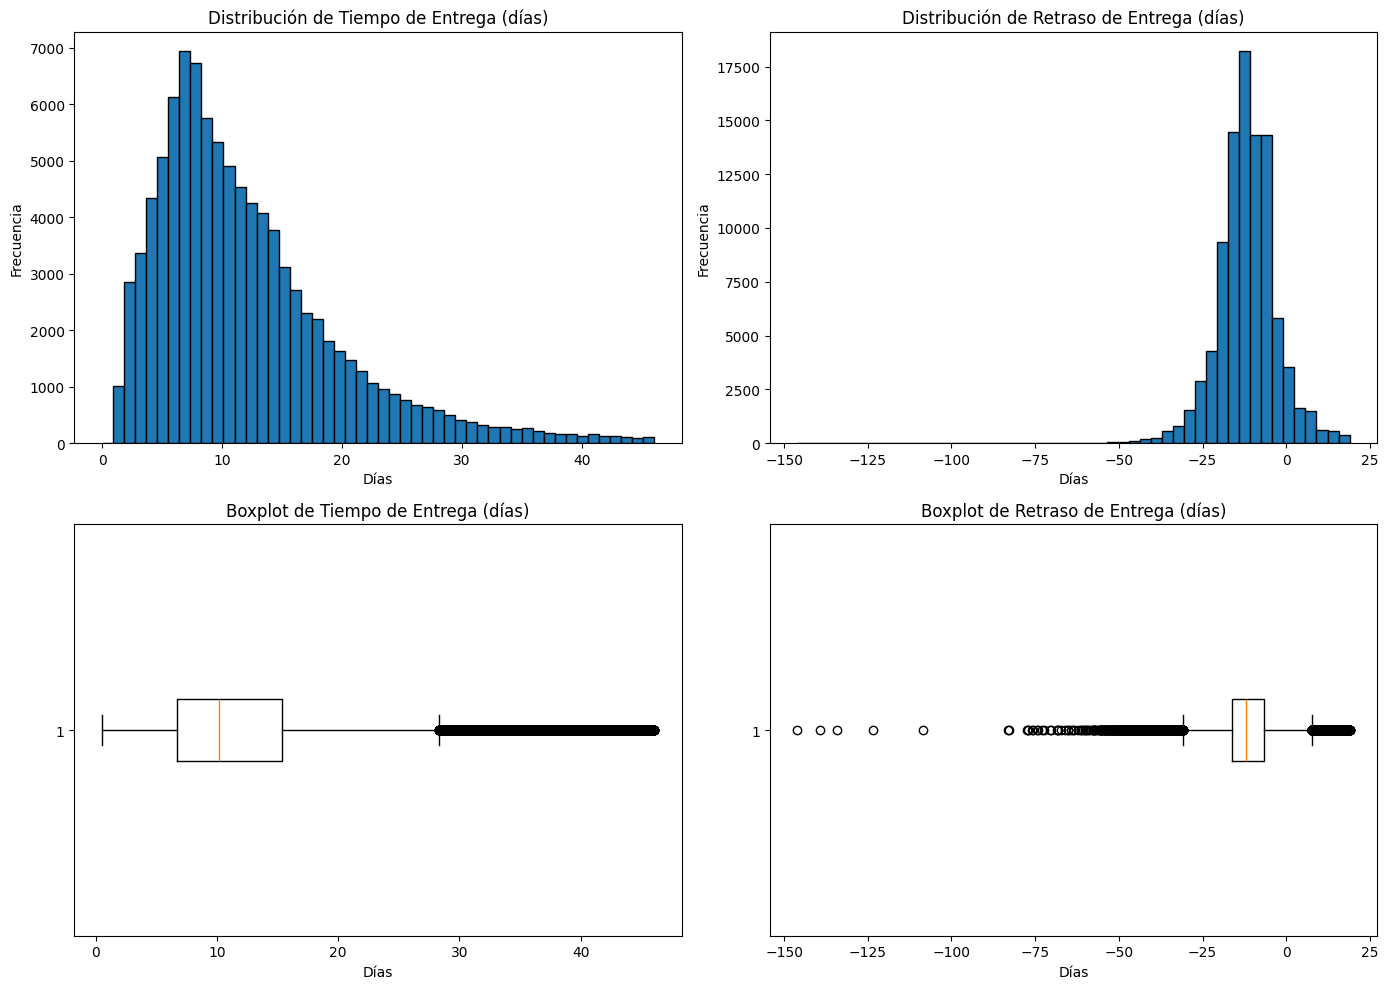

In [8]:
# Visualizaciones de distribución de tiempos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma de delivery_time_days (filtrado visualmente hasta p99)
p99_delivery = logistics_base['delivery_time_days'].quantile(0.99)
axes[0, 0].hist(logistics_base['delivery_time_days'], bins=50, range=(0, p99_delivery), edgecolor='black')
axes[0, 0].set_title('Distribución de Tiempo de Entrega (días)')
axes[0, 0].set_xlabel('Días')
axes[0, 0].set_ylabel('Frecuencia')

# Histograma de delivery_delay_days (filtrado visualmente hasta p99)
p99_delay = logistics_base['delivery_delay_days'].quantile(0.99)
axes[0, 1].hist(logistics_base['delivery_delay_days'], bins=50, range=(logistics_base['delivery_delay_days'].min(), p99_delay), edgecolor='black')
axes[0, 1].set_title('Distribución de Retraso de Entrega (días)')
axes[0, 1].set_xlabel('Días')
axes[0, 1].set_ylabel('Frecuencia')

# Boxplot de delivery_time_days (filtrado visualmente hasta p99)
axes[1, 0].boxplot(logistics_base['delivery_time_days'][logistics_base['delivery_time_days'] <= p99_delivery], vert=False)
axes[1, 0].set_title('Boxplot de Tiempo de Entrega (días)')
axes[1, 0].set_xlabel('Días')

# Boxplot de delivery_delay_days (filtrado visualmente hasta p99)
axes[1, 1].boxplot(logistics_base['delivery_delay_days'][(logistics_base['delivery_delay_days'] >= logistics_base['delivery_delay_days'].min()) & 
                                                         (logistics_base['delivery_delay_days'] <= p99_delay)], vert=False)
axes[1, 1].set_title('Boxplot de Retraso de Entrega (días)')
axes[1, 1].set_xlabel('Días')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'logistics_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Cumplimiento de promesa de entrega

In [9]:
# Crear variable delivery_status_detail
def get_delivery_status(delay):
    if pd.isna(delay):
        return "Sin dato"
    elif delay < 0:
        return "Temprano"
    elif delay == 0:
        return "A tiempo"
    else:
        return "Tarde"

logistics_base['delivery_status_detail'] = logistics_base['delivery_delay_days'].apply(get_delivery_status)

# Crear tabla con conteo y porcentaje por delivery_status_detail
delivery_promise_status = logistics_base['delivery_status_detail'].value_counts().reset_index()
delivery_promise_status.columns = ['delivery_status', 'count']
delivery_promise_status['percentage'] = (delivery_promise_status['count'] / len(logistics_base) * 100).round(2)

# Guardar en reports
delivery_promise_status.to_csv(REPORTS_DIR / 'delivery_promise_status.csv', index=False)

print("Cumplimiento de promesa de entrega:")
display(delivery_promise_status)

Cumplimiento de promesa de entrega:


,delivery_status,count,percentage
0,Temprano,88649,91.89
1,Tarde,7827,8.11


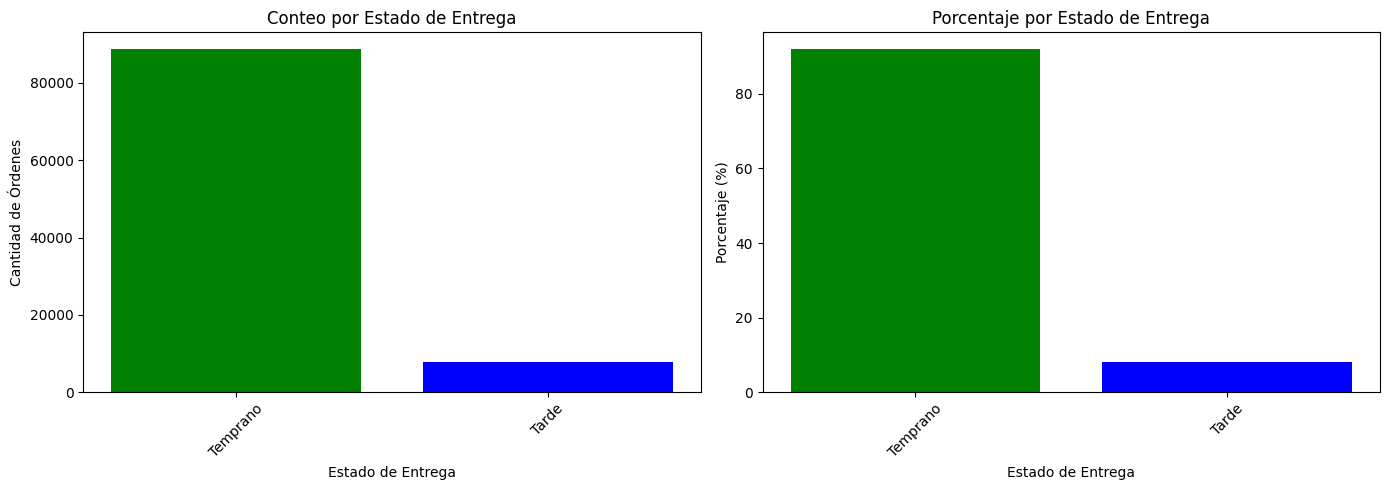

In [10]:
# Visualizaciones de cumplimiento de promesa de entrega
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras de conteo por delivery_status_detail
axes[0].bar(delivery_promise_status['delivery_status'], delivery_promise_status['count'], color=['green', 'blue', 'red', 'gray'])
axes[0].set_title('Conteo por Estado de Entrega')
axes[0].set_xlabel('Estado de Entrega')
axes[0].set_ylabel('Cantidad de Órdenes')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico de porcentaje por delivery_status_detail
axes[1].bar(delivery_promise_status['delivery_status'], delivery_promise_status['percentage'], color=['green', 'blue', 'red', 'gray'])
axes[1].set_title('Porcentaje por Estado de Entrega')
axes[1].set_xlabel('Estado de Entrega')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'delivery_promise_status.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Evolución mensual logística

In [11]:
# Crear variable purchase_year_month
logistics_base['purchase_year_month'] = logistics_base['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Agrupar por purchase_year_month
monthly_logistics = logistics_base.groupby('purchase_year_month').agg({
    'order_id': 'count',
    'delivery_time_days': ['mean', 'median'],
    'delivery_delay_days': 'mean',
    'is_late': 'mean',
    'total_freight': 'mean',
    'review_score_avg': 'mean',
    'bad_review': 'mean'
}).reset_index()

monthly_logistics.columns = ['purchase_year_month', 'delivered_orders', 'avg_delivery_time_days', 
                            'median_delivery_time_days', 'avg_delivery_delay_days', 'late_delivery_rate',
                            'avg_freight_value', 'avg_review_score', 'bad_review_rate']

# Convertir tasas a porcentaje
monthly_logistics['late_delivery_rate'] = (monthly_logistics['late_delivery_rate'] * 100).round(2)
monthly_logistics['bad_review_rate'] = (monthly_logistics['bad_review_rate'] * 100).round(2)

# Guardar en reports
monthly_logistics.to_csv(REPORTS_DIR / 'monthly_logistics_metrics.csv', index=False)

print("Evolución mensual logística:")
display(monthly_logistics.head())

Evolución mensual logística:


,purchase_year_month,delivered_orders,avg_delivery_time_days,median_delivery_time_days,avg_delivery_delay_days,late_delivery_rate,avg_freight_value,avg_review_score,bad_review_rate
0,2016-09,1,54.813194,54.813194,36.324745,100.00,8.490000,1.000000,100.00
1,2016-10,270,19.578572,17.921157,-36.059479,1.11,23.162407,3.970037,19.11
2,2016-12,1,4.693021,4.693021,-21.336991,0.00,8.720000,5.000000,0.00
3,2017-01,750,12.647044,10.733646,-26.861788,3.07,20.912013,4.199055,13.09
4,2017-02,1653,13.168825,10.971204,-18.680104,3.21,22.393176,4.202678,12.26


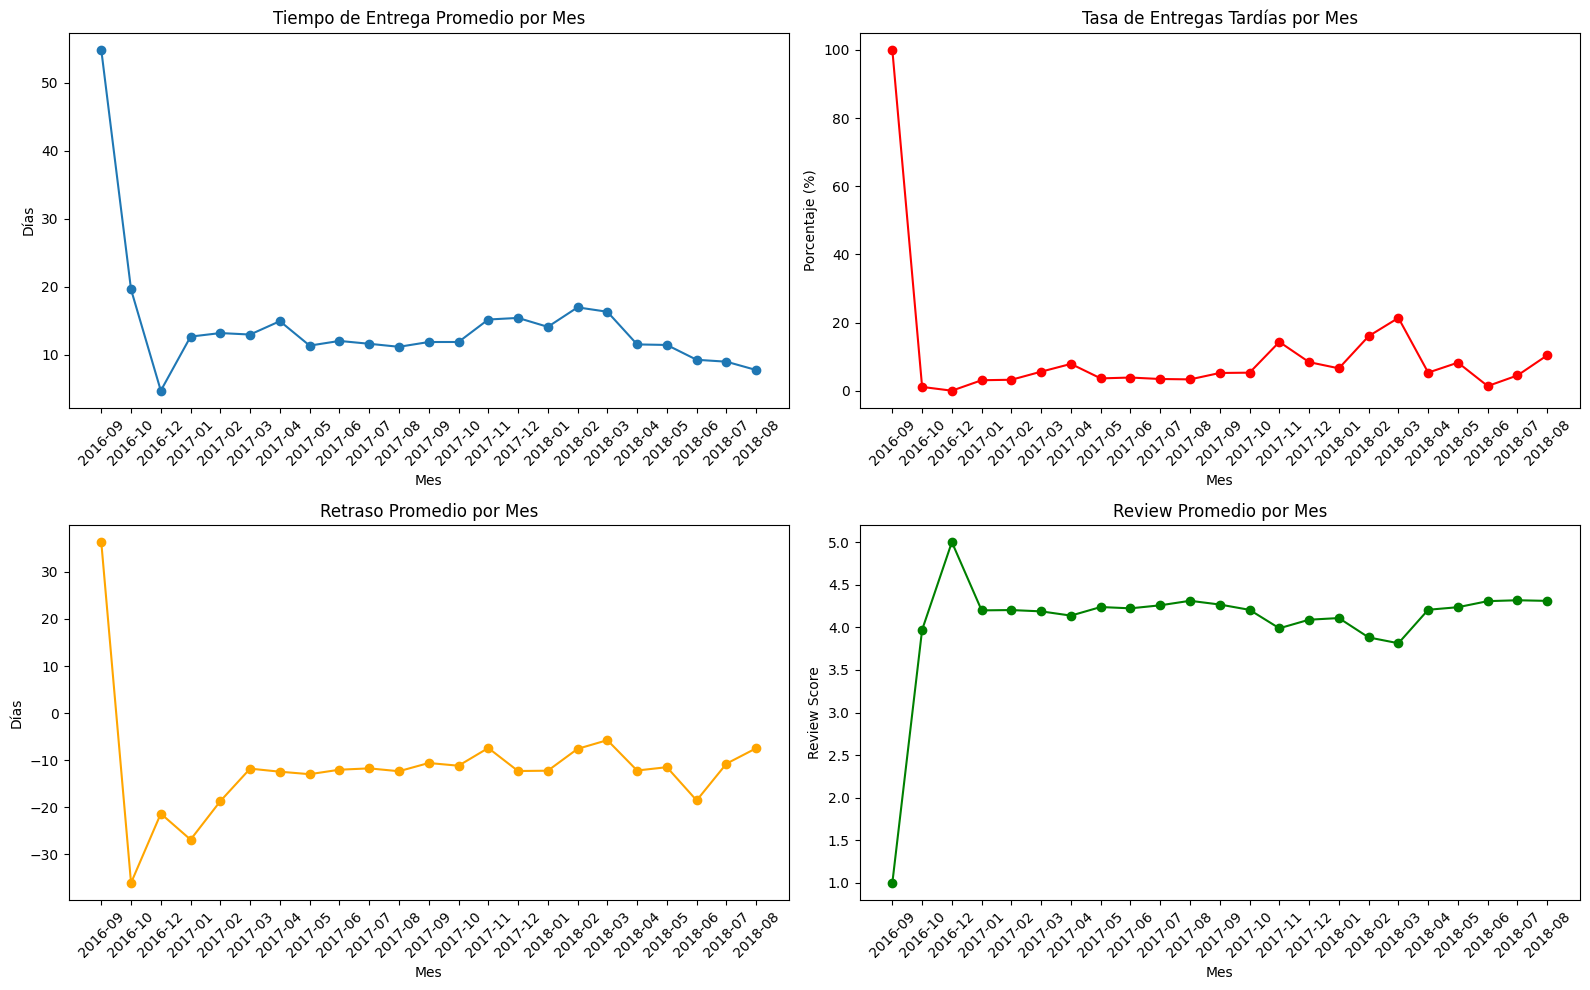

In [12]:
# Visualizaciones de evolución mensual
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Línea de avg_delivery_time_days por mes
axes[0, 0].plot(monthly_logistics['purchase_year_month'], monthly_logistics['avg_delivery_time_days'], marker='o')
axes[0, 0].set_title('Tiempo de Entrega Promedio por Mes')
axes[0, 0].set_xlabel('Mes')
axes[0, 0].set_ylabel('Días')
axes[0, 0].tick_params(axis='x', rotation=45)

# Línea de late_delivery_rate por mes
axes[0, 1].plot(monthly_logistics['purchase_year_month'], monthly_logistics['late_delivery_rate'], marker='o', color='red')
axes[0, 1].set_title('Tasa de Entregas Tardías por Mes')
axes[0, 1].set_xlabel('Mes')
axes[0, 1].set_ylabel('Porcentaje (%)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Línea de avg_delivery_delay_days por mes
axes[1, 0].plot(monthly_logistics['purchase_year_month'], monthly_logistics['avg_delivery_delay_days'], marker='o', color='orange')
axes[1, 0].set_title('Retraso Promedio por Mes')
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('Días')
axes[1, 0].tick_params(axis='x', rotation=45)

# Línea de avg_review_score por mes
axes[1, 1].plot(monthly_logistics['purchase_year_month'], monthly_logistics['avg_review_score'], marker='o', color='green')
axes[1, 1].set_title('Review Promedio por Mes')
axes[1, 1].set_xlabel('Mes')
axes[1, 1].set_ylabel('Review Score')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'monthly_logistics_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

**Nota:** Septiembre/octubre de 2018 pueden estar incompletos y deben analizarse con cuidado, ya que corresponden a los últimos meses del dataset y pueden tener datos parciales.

## 11. Análisis logístico por estado del cliente

In [13]:
# Agrupar logistics_base por customer_state
logistics_by_state = logistics_base.groupby('customer_state').agg({
    'order_id': 'count',
    'delivery_time_days': ['mean', 'median'],
    'delivery_delay_days': 'mean',
    'is_late': 'mean',
    'total_freight': 'mean',
    'freight_ratio': 'mean',
    'review_score_avg': 'mean',
    'bad_review': 'mean'
}).reset_index()

logistics_by_state.columns = ['customer_state', 'delivered_orders', 'avg_delivery_time_days',
                              'median_delivery_time_days', 'avg_delivery_delay_days', 'late_delivery_rate',
                              'avg_freight_value', 'avg_freight_ratio', 'avg_review_score', 'bad_review_rate']

# Convertir tasas a porcentaje
logistics_by_state['late_delivery_rate'] = (logistics_by_state['late_delivery_rate'] * 100).round(2)
logistics_by_state['bad_review_rate'] = (logistics_by_state['bad_review_rate'] * 100).round(2)

# Filtrar estados con mínimo 100 órdenes entregadas
logistics_by_state_filtered = logistics_by_state[logistics_by_state['delivered_orders'] >= 100].copy()

# Guardar en reports
logistics_by_state_filtered.to_csv(REPORTS_DIR / 'logistics_by_customer_state.csv', index=False)

print("Análisis logístico por estado del cliente (mínimo 100 órdenes):")
display(logistics_by_state_filtered.sort_values('delivered_orders', ascending=False).head())

Análisis logístico por estado del cliente (mínimo 100 órdenes):


,customer_state,delivered_orders,avg_delivery_time_days,median_delivery_time_days,avg_delivery_delay_days,late_delivery_rate,avg_freight_value,avg_freight_ratio,avg_review_score,bad_review_rate
25,SP,40495,8.761357,7.210289,-10.381190,5.89,17.335120,0.251466,4.246538,11.56
18,RJ,12353,15.310053,12.041308,-11.060399,13.47,23.944775,0.315624,3.964412,19.97
10,MG,11355,12.010258,10.313646,-12.536991,5.62,23.463139,0.315842,4.192362,12.78
22,RS,5344,15.300276,13.177488,-13.208489,7.15,24.805449,0.339061,4.185599,12.96
17,PR,4923,11.991582,10.425509,-12.619678,5.00,23.490817,0.334683,4.239592,11.73


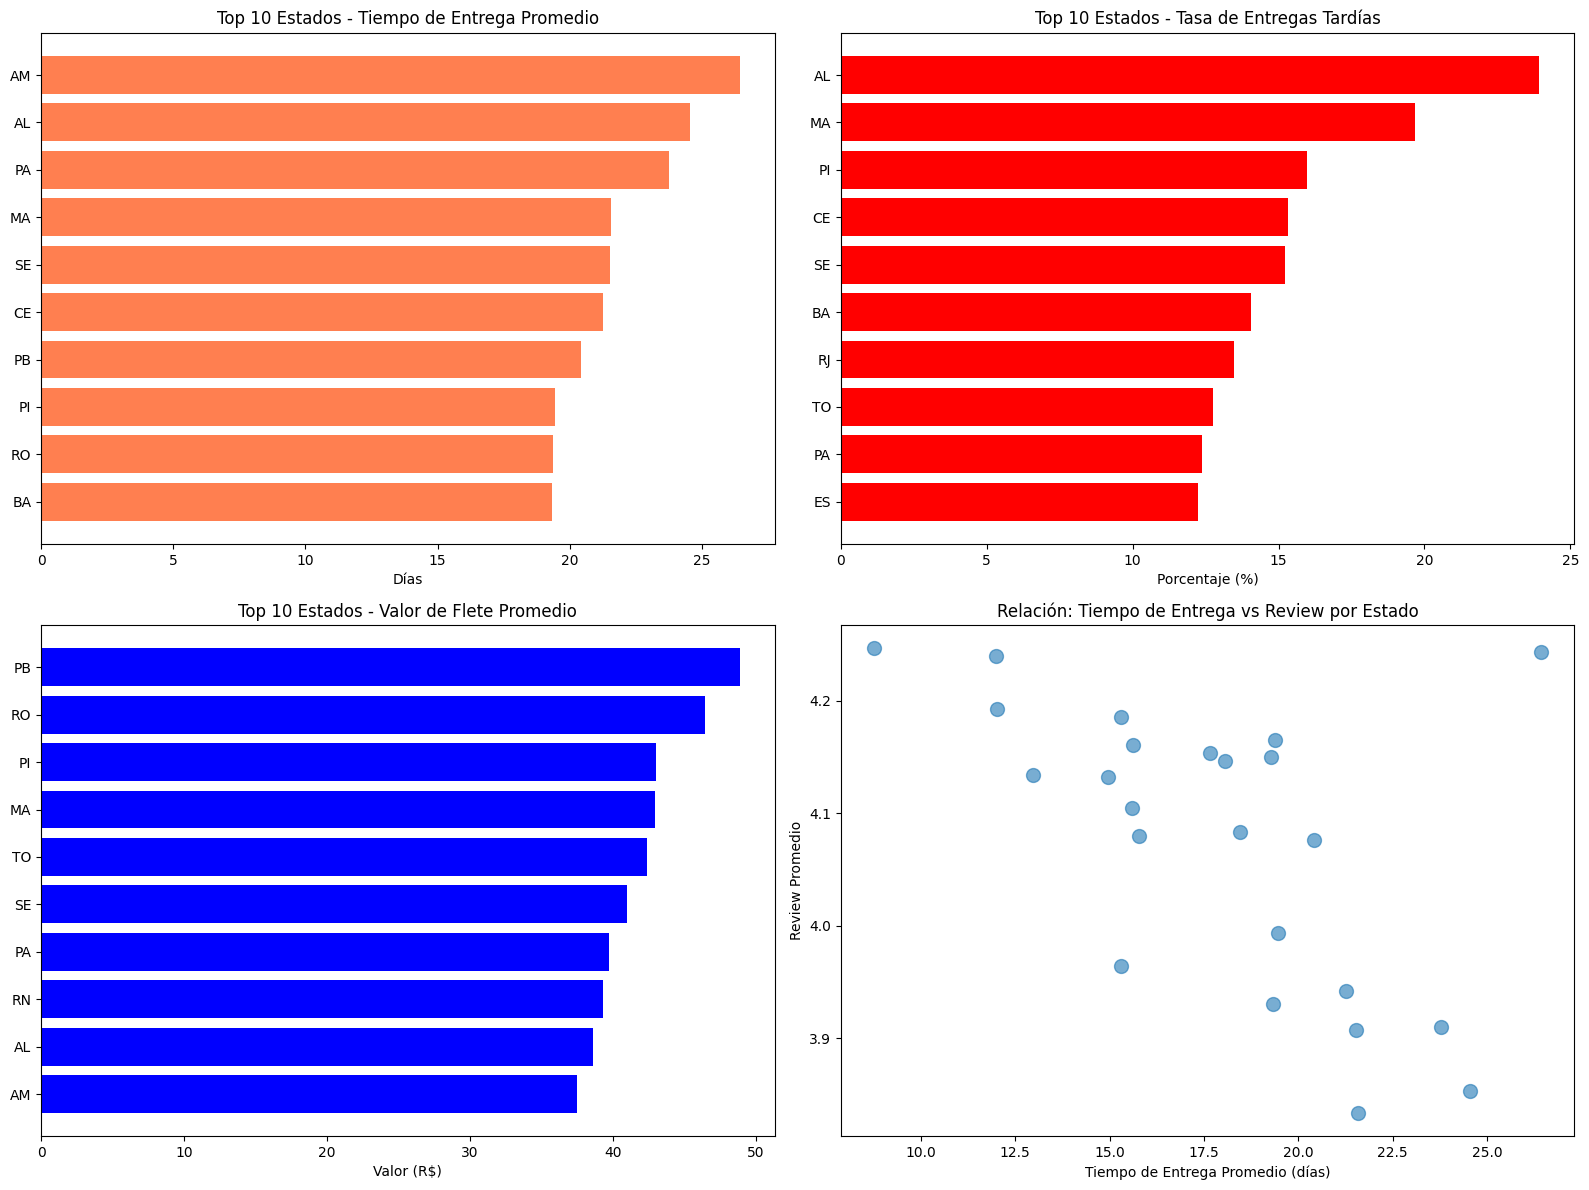

In [14]:
# Visualizaciones por estado del cliente
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 10 estados con mayor delivery_time_days promedio
top_delivery_time = logistics_by_state_filtered.nlargest(10, 'avg_delivery_time_days')
axes[0, 0].barh(top_delivery_time['customer_state'], top_delivery_time['avg_delivery_time_days'], color='coral')
axes[0, 0].set_title('Top 10 Estados - Tiempo de Entrega Promedio')
axes[0, 0].set_xlabel('Días')
axes[0, 0].invert_yaxis()

# Top 10 estados con mayor late_delivery_rate
top_late_rate = logistics_by_state_filtered.nlargest(10, 'late_delivery_rate')
axes[0, 1].barh(top_late_rate['customer_state'], top_late_rate['late_delivery_rate'], color='red')
axes[0, 1].set_title('Top 10 Estados - Tasa de Entregas Tardías')
axes[0, 1].set_xlabel('Porcentaje (%)')
axes[0, 1].invert_yaxis()

# Top 10 estados con mayor avg_freight_value
top_freight = logistics_by_state_filtered.nlargest(10, 'avg_freight_value')
axes[1, 0].barh(top_freight['customer_state'], top_freight['avg_freight_value'], color='blue')
axes[1, 0].set_title('Top 10 Estados - Valor de Flete Promedio')
axes[1, 0].set_xlabel('Valor (R$)')
axes[1, 0].invert_yaxis()

# Relación entre avg_delivery_time_days y avg_review_score por estado
axes[1, 1].scatter(logistics_by_state_filtered['avg_delivery_time_days'], 
                  logistics_by_state_filtered['avg_review_score'], 
                  alpha=0.6, s=100)
axes[1, 1].set_xlabel('Tiempo de Entrega Promedio (días)')
axes[1, 1].set_ylabel('Review Promedio')
axes[1, 1].set_title('Relación: Tiempo de Entrega vs Review por Estado')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'logistics_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Análisis logístico por categoría

In [15]:
# Agrupar logistics_base por main_category
logistics_by_category = logistics_base.groupby('main_category').agg({
    'order_id': 'count',
    'delivery_time_days': ['mean', 'median'],
    'delivery_delay_days': 'mean',
    'is_late': 'mean',
    'total_freight': 'mean',
    'freight_ratio': 'mean',
    'review_score_avg': 'mean',
    'bad_review': 'mean'
}).reset_index()

logistics_by_category.columns = ['main_category', 'delivered_orders', 'avg_delivery_time_days',
                                 'median_delivery_time_days', 'avg_delivery_delay_days', 'late_delivery_rate',
                                 'avg_freight_value', 'avg_freight_ratio', 'avg_review_score', 'bad_review_rate']

# Convertir tasas a porcentaje
logistics_by_category['late_delivery_rate'] = (logistics_by_category['late_delivery_rate'] * 100).round(2)
logistics_by_category['bad_review_rate'] = (logistics_by_category['bad_review_rate'] * 100).round(2)

# Filtrar categorías con mínimo 100 órdenes entregadas
logistics_by_category_filtered = logistics_by_category[logistics_by_category['delivered_orders'] >= 100].copy()

# Guardar en reports
logistics_by_category_filtered.to_csv(REPORTS_DIR / 'logistics_by_category.csv', index=False)

print("Análisis logístico por categoría (mínimo 100 órdenes):")
display(logistics_by_category_filtered.sort_values('delivered_orders', ascending=False).head())

Análisis logístico por categoría (mínimo 100 órdenes):


,main_category,delivered_orders,avg_delivery_time_days,median_delivery_time_days,avg_delivery_delay_days,late_delivery_rate,avg_freight_value,avg_freight_ratio,avg_review_score,bad_review_rate
7,bed_bath_table,9239,13.003091,10.738993,-10.672619,8.78,22.147394,0.271668,4.003390,17.58
43,health_beauty,8623,12.092879,9.565509,-11.271794,8.99,20.789254,0.278775,4.232230,12.30
65,sports_leisure,7478,12.260486,10.117922,-11.140727,7.78,21.773506,0.281937,4.237557,12.01
15,computers_accessories,6519,13.178062,11.109317,-11.674896,7.72,22.205541,0.298022,4.082768,15.76
39,furniture_decor,6208,13.115561,10.902043,-11.579241,8.57,27.232068,0.324758,4.073109,16.40


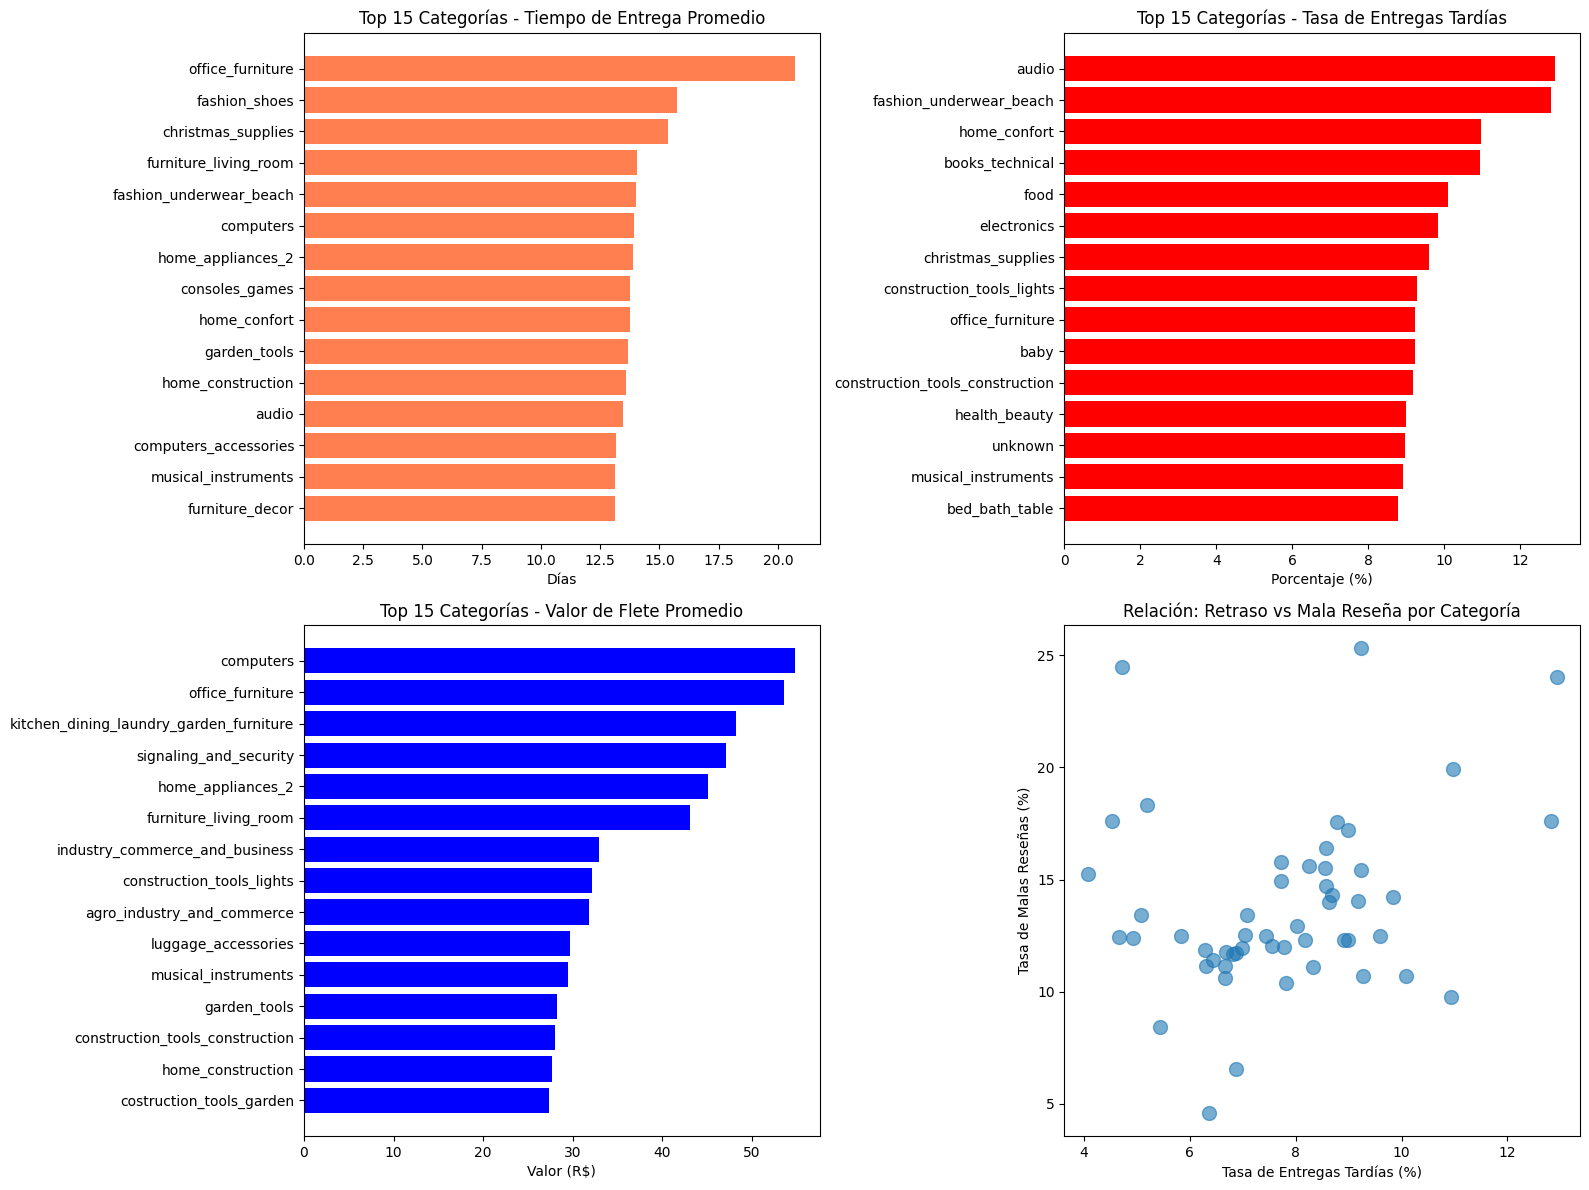

In [16]:
# Visualizaciones por categoría
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 15 categorías con mayor delivery_time_days promedio
top_cat_delivery_time = logistics_by_category_filtered.nlargest(15, 'avg_delivery_time_days')
axes[0, 0].barh(top_cat_delivery_time['main_category'], top_cat_delivery_time['avg_delivery_time_days'], color='coral')
axes[0, 0].set_title('Top 15 Categorías - Tiempo de Entrega Promedio')
axes[0, 0].set_xlabel('Días')
axes[0, 0].invert_yaxis()

# Top 15 categorías con mayor late_delivery_rate
top_cat_late_rate = logistics_by_category_filtered.nlargest(15, 'late_delivery_rate')
axes[0, 1].barh(top_cat_late_rate['main_category'], top_cat_late_rate['late_delivery_rate'], color='red')
axes[0, 1].set_title('Top 15 Categorías - Tasa de Entregas Tardías')
axes[0, 1].set_xlabel('Porcentaje (%)')
axes[0, 1].invert_yaxis()

# Top 15 categorías con mayor avg_freight_value
top_cat_freight = logistics_by_category_filtered.nlargest(15, 'avg_freight_value')
axes[1, 0].barh(top_cat_freight['main_category'], top_cat_freight['avg_freight_value'], color='blue')
axes[1, 0].set_title('Top 15 Categorías - Valor de Flete Promedio')
axes[1, 0].set_xlabel('Valor (R$)')
axes[1, 0].invert_yaxis()

# Relación entre late_delivery_rate y bad_review_rate por categoría
axes[1, 1].scatter(logistics_by_category_filtered['late_delivery_rate'], 
                  logistics_by_category_filtered['bad_review_rate'], 
                  alpha=0.6, s=100)
axes[1, 1].set_xlabel('Tasa de Entregas Tardías (%)')
axes[1, 1].set_ylabel('Tasa de Malas Reseñas (%)')
axes[1, 1].set_title('Relación: Retraso vs Mala Reseña por Categoría')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'logistics_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Distancia aproximada cliente-vendedor

In [17]:
# Función haversine para calcular distancia aproximada en kilómetros
def haversine(lat1, lon1, lat2, lon2):
    """
    Calcula la distancia aproximada en kilómetros entre dos coordenadas
    usando la fórmula de Haversine.
    """
    R = 6371  # Radio de la Tierra en kilómetros
    
    # Convertir a radianes
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    
    # Diferencias
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Fórmula de Haversine
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))
    
    return R * c

In [24]:
# Construir tabla order_seller_distance
print("Construyendo tabla de distancia cliente-vendedor...")

# 1. Tomar olist_order_items_dataset.csv con order_id y seller_id
order_seller = order_items[['order_id', 'seller_id']].copy()

# 2. Eliminar duplicados order_id-seller_id
order_seller = order_seller.drop_duplicates()

# 3. Unir con dim_sellers para obtener seller_zip_code_prefix, seller_state, seller_city
order_seller = order_seller.merge(
    dim_sellers[['seller_id', 'seller_zip_code_prefix', 'seller_state', 'seller_city']],
    on='seller_id',
    how='left'
)

# 4. Unir con fact_orders para obtener customer_zip_code_prefix, customer_state, customer_city
order_seller = order_seller.merge(
    fact_orders[['order_id', 'customer_zip_code_prefix', 'customer_state', 'customer_city']],
    on='order_id',
    how='left'
)

# 5. Unir con dim_geolocation_zip para obtener coordenadas del cliente
order_seller = order_seller.merge(
    dim_geolocation_zip[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']],
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)
order_seller = order_seller.rename(columns={'geolocation_lat': 'customer_lat', 'geolocation_lng': 'customer_lng'})
order_seller = order_seller.drop(columns=['geolocation_zip_code_prefix'])

# 6. Unir con dim_geolocation_zip para obtener coordenadas del vendedor
order_seller = order_seller.merge(
    dim_geolocation_zip[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']],
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)
order_seller = order_seller.rename(columns={'geolocation_lat': 'seller_lat', 'geolocation_lng': 'seller_lng'})
order_seller = order_seller.drop(columns=['geolocation_zip_code_prefix'])

print(f"Filas en order_seller antes de calcular distancia: {len(order_seller)}")
print(f"Coordenadas de cliente disponibles: {order_seller['customer_lat'].notna().sum()}")
print(f"Coordenadas de vendedor disponibles: {order_seller['seller_lat'].notna().sum()}")

Construyendo tabla de distancia cliente-vendedor...
Filas en order_seller antes de calcular distancia: 100010
Coordenadas de cliente disponibles: 99730
Coordenadas de vendedor disponibles: 99790


In [21]:
# Crear comparaciones de satisfacción
# 1. Review promedio entre órdenes tardías y no tardías
review_by_late = logistics_base.groupby('is_late')['review_score_avg'].mean()
# 2. Bad review rate entre órdenes tardías y no tardías
bad_review_by_late = logistics_base.groupby('is_late')['bad_review'].mean() * 100
# 3. Delivery_time_days promedio por review_score_avg redondeado
logistics_base['review_score_rounded'] = logistics_base['review_score_avg'].round()
delivery_time_by_review = logistics_base.groupby('review_score_rounded')['delivery_time_days'].mean()
# 4. Delivery_delay_days promedio por review_score_avg redondeado
delay_by_review = logistics_base.groupby('review_score_rounded')['delivery_delay_days'].mean()

# Crear tabla logistics_satisfaction_impact
logistics_satisfaction_impact = pd.DataFrame({
    'metric': [
        'avg_review_late_orders',
        'avg_review_on_time_orders',
        'bad_review_rate_late_orders',
        'bad_review_rate_on_time_orders'
    ],
    'value': [
        review_by_late[1] if 1 in review_by_late.index else None,
        review_by_late[0] if 0 in review_by_late.index else None,
        bad_review_by_late[1] if 1 in bad_review_by_late.index else None,
        bad_review_by_late[0] if 0 in bad_review_by_late.index else None
    ]
})

# Agregar métricas por review score
new_rows = []
for score in sorted(logistics_base['review_score_rounded'].unique()):
    if pd.notna(score):
        new_rows.append({
            'metric': f'delivery_time_review_score_{int(score)}',
            'value': delivery_time_by_review[score] if score in delivery_time_by_review.index else None
        })
        new_rows.append({
            'metric': f'delivery_delay_review_score_{int(score)}',
            'value': delay_by_review[score] if score in delay_by_review.index else None
        })

logistics_satisfaction_impact = pd.concat([logistics_satisfaction_impact, pd.DataFrame(new_rows)], ignore_index=True)

# Guardar en reports
logistics_satisfaction_impact.to_csv(REPORTS_DIR / 'logistics_satisfaction_impact.csv', index=False)

print("Impacto logístico en satisfacción:")
display(logistics_satisfaction_impact)

Impacto logístico en satisfacción:


,metric,value
0,avg_review_late_orders,2.566562
1,avg_review_on_time_orders,4.294151
2,bad_review_rate_late_orders,60.966981
3,bad_review_rate_on_time_orders,9.995560
4,delivery_time_review_score_1,21.339995
5,delivery_delay_review_score_1,-3.336156
6,delivery_time_review_score_2,16.686322
7,delivery_delay_review_score_2,-7.920144
8,delivery_time_review_score_3,14.247096
9,delivery_delay_review_score_3,-10.084795


In [25]:
# 7. Calcular distance_km usando haversine
def calculate_distance_row(row):
    if pd.isna(row['customer_lat']) or pd.isna(row['customer_lng']) or pd.isna(row['seller_lat']) or pd.isna(row['seller_lng']):
        return np.nan
    return haversine(row['customer_lat'], row['customer_lng'], row['seller_lat'], row['seller_lng'])

print("Calculando distancias...")
order_seller['distance_km'] = order_seller.apply(calculate_distance_row, axis=1)

print(f"Distancias calculadas: {order_seller['distance_km'].notna().sum()}")
print(f"Distancias no disponibles: {order_seller['distance_km'].isna().sum()}")

Calculando distancias...
Distancias calculadas: 99511
Distancias no disponibles: 499


In [26]:
# 8. Agregar a nivel order_id
order_distance_agg = order_seller.groupby('order_id').agg({
    'distance_km': ['mean', 'max', 'min', 'count'],
    'seller_state': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0] if len(x) > 0 else None
}).reset_index()

order_distance_agg.columns = ['order_id', 'avg_distance_km', 'max_distance_km', 'min_distance_km', 
                              'sellers_in_distance_table', 'main_seller_state']

# Calcular seller_states_count
order_distance_agg['seller_states_count'] = order_seller.groupby('order_id')['seller_state'].nunique().values

print("Estadísticas de distancia agregada:")
print(order_distance_agg[['avg_distance_km', 'max_distance_km', 'min_distance_km']].describe())

# Guardar en data/processed y reports
order_distance_agg.to_csv(DATA_PROCESSED_DIR / 'order_distance_agg.csv', index=False)
order_distance_agg.head(1000).to_csv(REPORTS_DIR / 'order_distance_agg_sample.csv', index=False)

print(f"\nTabla guardada en {DATA_PROCESSED_DIR / 'order_distance_agg.csv'}")
print(f"Muestra guardada en {REPORTS_DIR / 'order_distance_agg_sample.csv'}")

Estadísticas de distancia agregada:
       avg_distance_km  max_distance_km  min_distance_km
count     98177.000000     98177.000000     98177.000000
mean        601.591461       602.896657       600.291887
std         595.311967       595.793491       595.413151
min           0.000000         0.000000         0.000000
25%         186.517895       188.273804       182.012384
50%         433.768698       435.389341       431.838440
75%         798.023379       800.721668       797.181399
max        8677.859564      8677.859564      8677.859564

Tabla guardada en c:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\data\processed\order_distance_agg.csv
Muestra guardada en c:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\reports\order_distance_agg_sample.csv


## 14. Enriquecer logistics_base con distancia

In [27]:
# Unir logistics_base con order_distance_agg usando order_id
logistics_enriched = logistics_base.merge(
    order_distance_agg,
    on='order_id',
    how='left'
)

# Guardar en data/processed
logistics_enriched.to_csv(DATA_PROCESSED_DIR / 'logistics_enriched.csv', index=False)

# Validar
total_enriched = len(logistics_enriched)
distance_available = logistics_enriched['avg_distance_km'].notna().sum()
distance_coverage = (distance_available / total_enriched * 100) if total_enriched > 0 else 0
distance_nulls = logistics_enriched['avg_distance_km'].isna().sum()

print("Validación de logistics_enriched:")
print(f"  Filas de logistics_enriched: {total_enriched:,}")
print(f"  Porcentaje de órdenes entregadas con distancia disponible: {distance_coverage:.2f}%")
print(f"  Nulos en avg_distance_km: {distance_nulls:,}")

Validación de logistics_enriched:
  Filas de logistics_enriched: 96,476
  Porcentaje de órdenes entregadas con distancia disponible: 99.51%
  Nulos en avg_distance_km: 476


## 15. Relación entre distancia, flete, tiempo y satisfacción

In [28]:
# Usar logistics_enriched con avg_distance_km no nulo
logistics_distance = logistics_enriched[logistics_enriched['avg_distance_km'].notna()].copy()

# Crear tabla distance_metrics_summary con percentiles
distance_metrics = ['avg_distance_km', 'total_freight', 'freight_ratio', 
                    'delivery_time_days', 'delivery_delay_days', 'review_score_avg']

distance_metrics_summary = pd.DataFrame()
for metric in distance_metrics:
    metric_data = logistics_distance[metric].dropna()
    distance_metrics_summary[metric] = [
        metric_data.mean(),
        metric_data.median(),
        metric_data.quantile(0.25),
        metric_data.quantile(0.75),
        metric_data.quantile(0.90),
        metric_data.quantile(0.95),
        metric_data.quantile(0.99),
        metric_data.min(),
        metric_data.max()
    ]

distance_metrics_summary.index = ['mean', 'median', 'p25', 'p75', 'p90', 'p95', 'p99', 'min', 'max']

# Guardar en reports
distance_metrics_summary.to_csv(REPORTS_DIR / 'distance_metrics_summary.csv')

print("Resumen de métricas por distancia:")
display(distance_metrics_summary)

Resumen de métricas por distancia:


,avg_distance_km,total_freight,freight_ratio,delivery_time_days,delivery_delay_days,review_score_avg
mean,600.701342,22.77867,0.308343,12.549518,-11.185744,4.155825
median,433.870939,17.16000,0.224374,10.210260,-11.955978,5.000000
p25,186.872620,13.83000,0.132010,6.758270,-16.246412,4.000000
p75,797.335161,24.00000,0.380438,15.704057,-6.390518,5.000000
p90,1456.594879,39.38000,0.622148,23.089556,-1.138359,5.000000
p95,2095.563790,54.74100,0.838889,29.267697,3.808834,5.000000
p99,2482.872000,104.26110,1.460419,46.030820,18.905521,5.000000
min,0.000000,0.00000,0.000000,0.533414,-146.016123,1.000000
max,8677.859564,1794.96000,21.447059,209.628611,188.975081,5.000000


In [29]:
# Crear bins de distancia
def get_distance_range(distance):
    if pd.isna(distance):
        return "Sin dato"
    elif distance < 100:
        return "0-100 km"
    elif distance < 300:
        return "100-300 km"
    elif distance < 600:
        return "300-600 km"
    elif distance < 1000:
        return "600-1000 km"
    else:
        return "1000+ km"

logistics_distance['distance_range'] = logistics_distance['avg_distance_km'].apply(get_distance_range)

# Agrupar por distance_range
logistics_by_distance = logistics_distance.groupby('distance_range').agg({
    'order_id': 'count',
    'avg_distance_km': 'mean',
    'delivery_time_days': 'mean',
    'delivery_delay_days': 'mean',
    'is_late': 'mean',
    'total_freight': 'mean',
    'freight_ratio': 'mean',
    'review_score_avg': 'mean',
    'bad_review': 'mean'
}).reset_index()

logistics_by_distance.columns = ['distance_range', 'orders', 'avg_distance_km', 'avg_delivery_time_days',
                                'avg_delivery_delay_days', 'late_delivery_rate', 'avg_freight_value',
                                'avg_freight_ratio', 'avg_review_score', 'bad_review_rate']

# Convertir tasas a porcentaje
logistics_by_distance['late_delivery_rate'] = (logistics_by_distance['late_delivery_rate'] * 100).round(2)
logistics_by_distance['bad_review_rate'] = (logistics_by_distance['bad_review_rate'] * 100).round(2)

# Ordenar por rango de distancia
distance_order = ["0-100 km", "100-300 km", "300-600 km", "600-1000 km", "1000+ km", "Sin dato"]
logistics_by_distance['distance_range'] = pd.Categorical(logistics_by_distance['distance_range'], 
                                                         categories=distance_order, ordered=True)
logistics_by_distance = logistics_by_distance.sort_values('distance_range')

# Guardar en reports
logistics_by_distance.to_csv(REPORTS_DIR / 'logistics_by_distance_range.csv', index=False)

print("Análisis por rango de distancia:")
display(logistics_by_distance)

Análisis por rango de distancia:


,distance_range,orders,avg_distance_km,avg_delivery_time_days,avg_delivery_delay_days,late_delivery_rate,avg_freight_value,avg_freight_ratio,avg_review_score,bad_review_rate
0,0-100 km,17822,40.065410,6.512372,-8.793608,6.43,13.344640,0.227797,4.277878,11.09
1,100-300 km,13426,200.324939,9.959158,-10.846713,6.38,18.831835,0.254183,4.240519,11.93
3,300-600 km,31496,430.018477,12.628889,-11.693702,7.77,22.395344,0.308429,4.134402,14.60
4,600-1000 km,17916,784.472686,14.718624,-12.136828,8.45,24.839843,0.335256,4.120429,14.51
2,1000+ km,15340,1738.281997,19.134304,-12.107921,11.82,35.573241,0.417712,4.024938,17.04


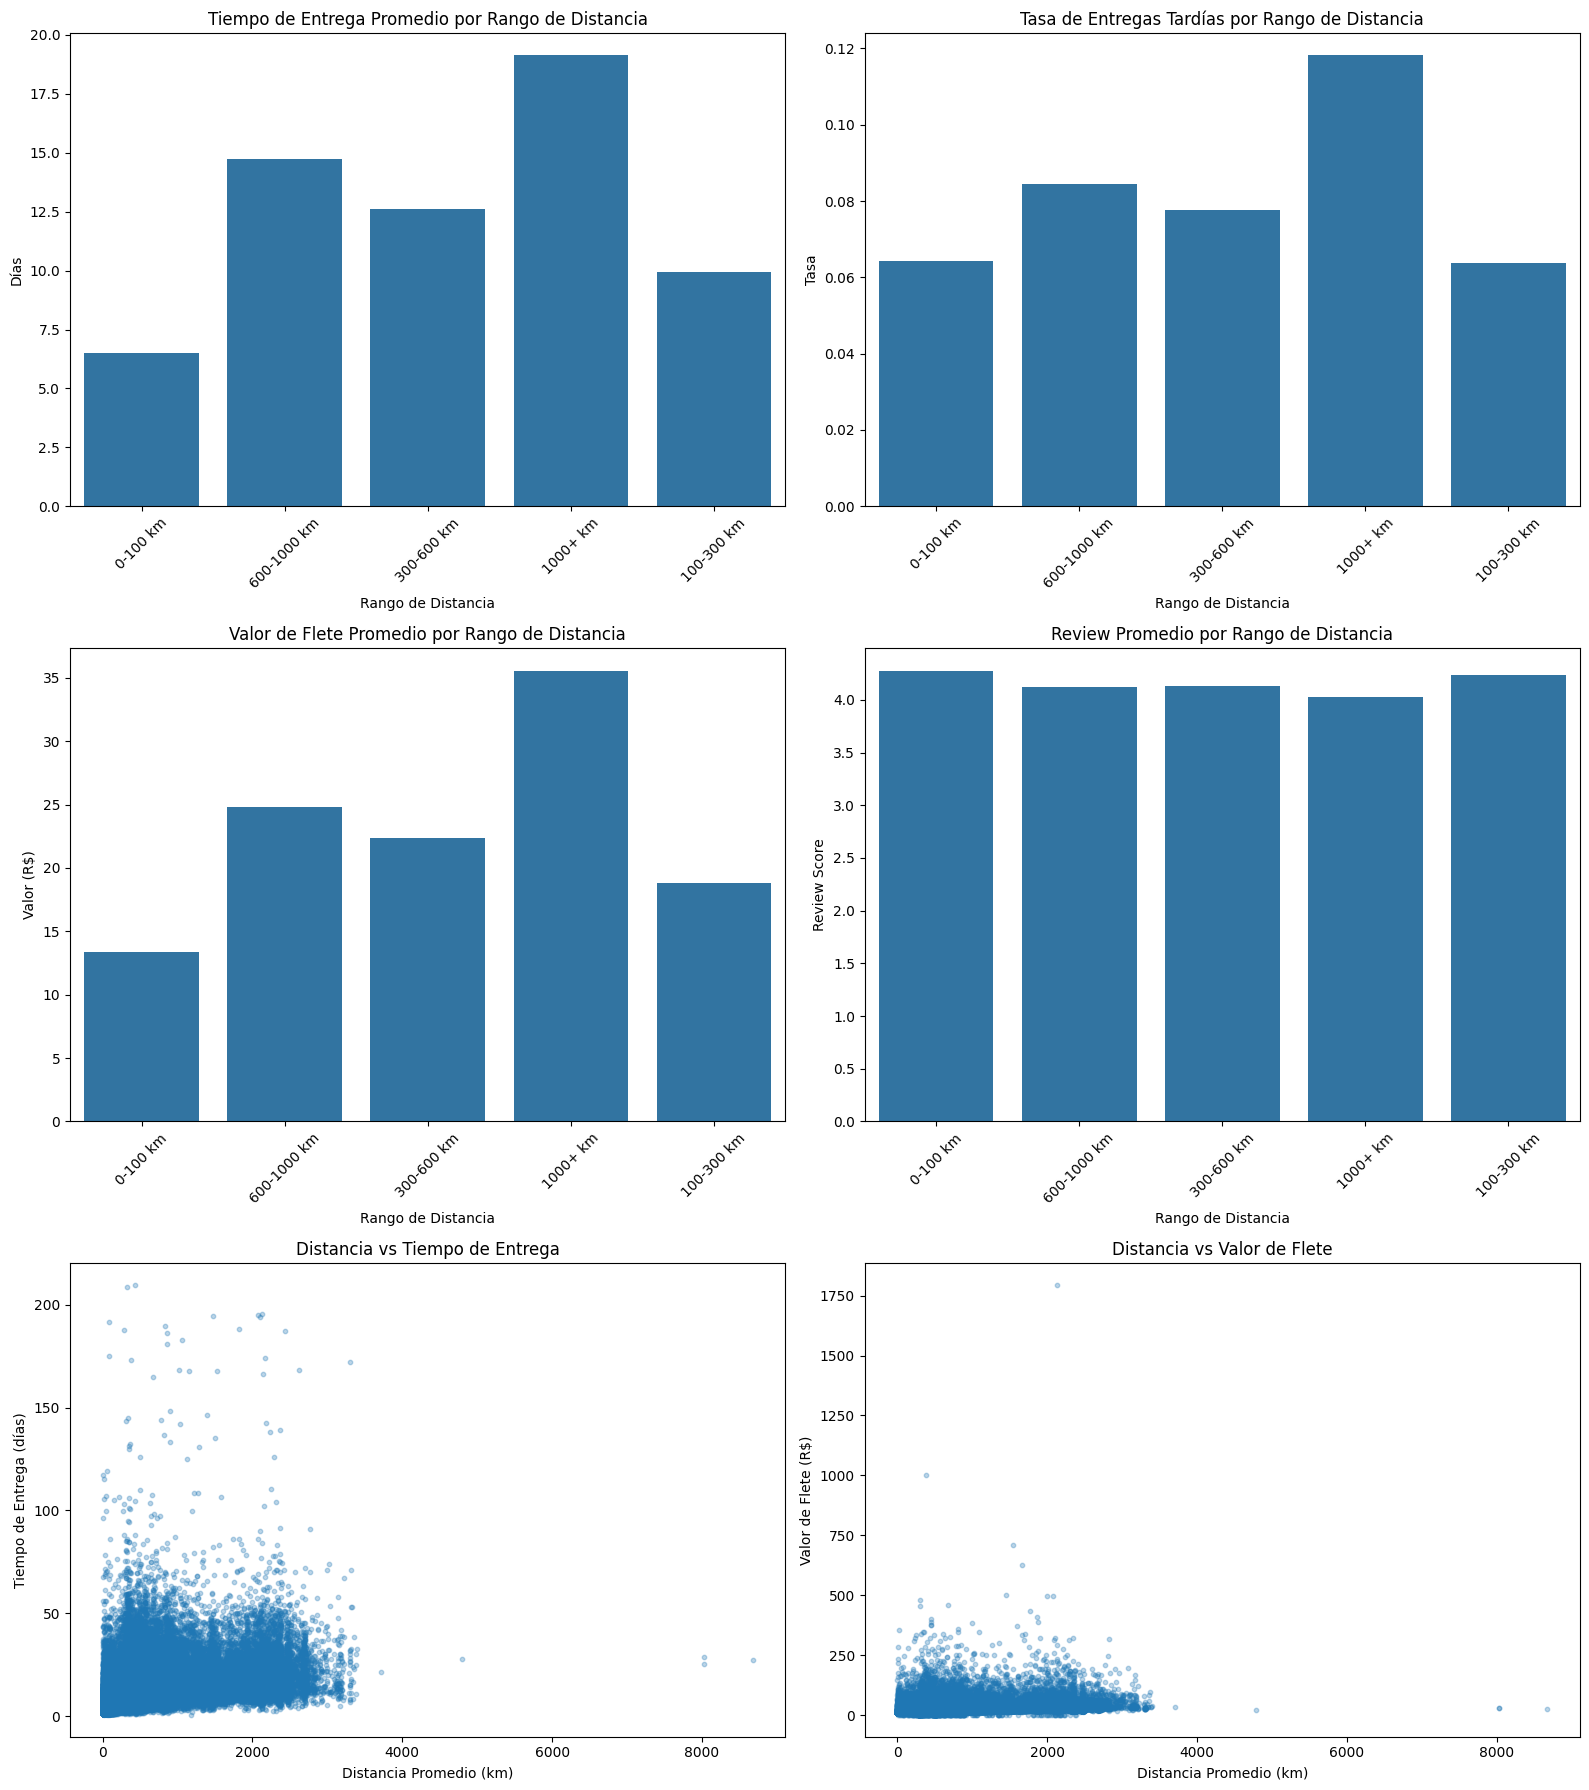

In [30]:
# Visualizaciones por rango de distancia
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Filtrar "Sin dato" para visualizaciones
logistics_distance_viz = logistics_distance[logistics_distance['distance_range'] != "Sin dato"]

# avg_delivery_time_days por rango de distancia
sns.barplot(data=logistics_distance_viz, x='distance_range', y='delivery_time_days', ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title('Tiempo de Entrega Promedio por Rango de Distancia')
axes[0, 0].set_xlabel('Rango de Distancia')
axes[0, 0].set_ylabel('Días')
axes[0, 0].tick_params(axis='x', rotation=45)

# late_delivery_rate por rango de distancia
sns.barplot(data=logistics_distance_viz, x='distance_range', y='is_late', ax=axes[0, 1], errorbar=None)
axes[0, 1].set_title('Tasa de Entregas Tardías por Rango de Distancia')
axes[0, 1].set_xlabel('Rango de Distancia')
axes[0, 1].set_ylabel('Tasa')
axes[0, 1].tick_params(axis='x', rotation=45)

# avg_freight_value por rango de distancia
sns.barplot(data=logistics_distance_viz, x='distance_range', y='total_freight', ax=axes[1, 0], errorbar=None)
axes[1, 0].set_title('Valor de Flete Promedio por Rango de Distancia')
axes[1, 0].set_xlabel('Rango de Distancia')
axes[1, 0].set_ylabel('Valor (R$)')
axes[1, 0].tick_params(axis='x', rotation=45)

# avg_review_score por rango de distancia
sns.barplot(data=logistics_distance_viz, x='distance_range', y='review_score_avg', ax=axes[1, 1], errorbar=None)
axes[1, 1].set_title('Review Promedio por Rango de Distancia')
axes[1, 1].set_xlabel('Rango de Distancia')
axes[1, 1].set_ylabel('Review Score')
axes[1, 1].tick_params(axis='x', rotation=45)

# scatter avg_distance_km vs delivery_time_days
axes[2, 0].scatter(logistics_distance['avg_distance_km'], logistics_distance['delivery_time_days'], alpha=0.3, s=10)
axes[2, 0].set_title('Distancia vs Tiempo de Entrega')
axes[2, 0].set_xlabel('Distancia Promedio (km)')
axes[2, 0].set_ylabel('Tiempo de Entrega (días)')

# scatter avg_distance_km vs total_freight
axes[2, 1].scatter(logistics_distance['avg_distance_km'], logistics_distance['total_freight'], alpha=0.3, s=10)
axes[2, 1].set_title('Distancia vs Valor de Flete')
axes[2, 1].set_xlabel('Distancia Promedio (km)')
axes[2, 1].set_ylabel('Valor de Flete (R$)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'logistics_by_distance.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Análisis por estado vendedor

In [31]:
# Usar logistics_enriched
logistics_seller_state = logistics_enriched.groupby('main_seller_state').agg({
    'order_id': 'count',
    'avg_distance_km': 'mean',
    'delivery_time_days': 'mean',
    'delivery_delay_days': 'mean',
    'is_late': 'mean',
    'total_freight': 'mean',
    'review_score_avg': 'mean',
    'bad_review': 'mean'
}).reset_index()

logistics_seller_state.columns = ['main_seller_state', 'delivered_orders', 'avg_distance_km',
                                  'avg_delivery_time_days', 'avg_delivery_delay_days', 'late_delivery_rate',
                                  'avg_freight_value', 'avg_review_score', 'bad_review_rate']

# Convertir tasas a porcentaje
logistics_seller_state['late_delivery_rate'] = (logistics_seller_state['late_delivery_rate'] * 100).round(2)
logistics_seller_state['bad_review_rate'] = (logistics_seller_state['bad_review_rate'] * 100).round(2)

# Filtrar estados vendedor con mínimo 100 órdenes
logistics_seller_state_filtered = logistics_seller_state[logistics_seller_state['delivered_orders'] >= 100].copy()

# Guardar en reports
logistics_seller_state_filtered.to_csv(REPORTS_DIR / 'logistics_by_seller_state.csv', index=False)

print("Análisis por estado vendedor (mínimo 100 órdenes):")
display(logistics_seller_state_filtered.sort_values('delivered_orders', ascending=False).head())

Análisis por estado vendedor (mínimo 100 órdenes):


,main_seller_state,delivered_orders,avg_distance_km,avg_delivery_time_days,avg_delivery_delay_days,late_delivery_rate,avg_freight_value,avg_review_score,bad_review_rate
21,SP,68223,542.133144,12.372358,-10.407214,8.79,21.085873,4.132466,14.49
7,MG,7722,600.512227,12.837741,-12.677744,5.59,27.191869,4.228683,11.85
14,PR,7485,720.857812,13.405362,-13.414570,6.48,26.009376,4.187248,13.38
15,RJ,4215,583.363893,12.076014,-11.759421,8.42,21.953575,4.226284,13.01
19,SC,3571,749.423374,13.741610,-13.357628,6.02,29.389835,4.181869,13.52


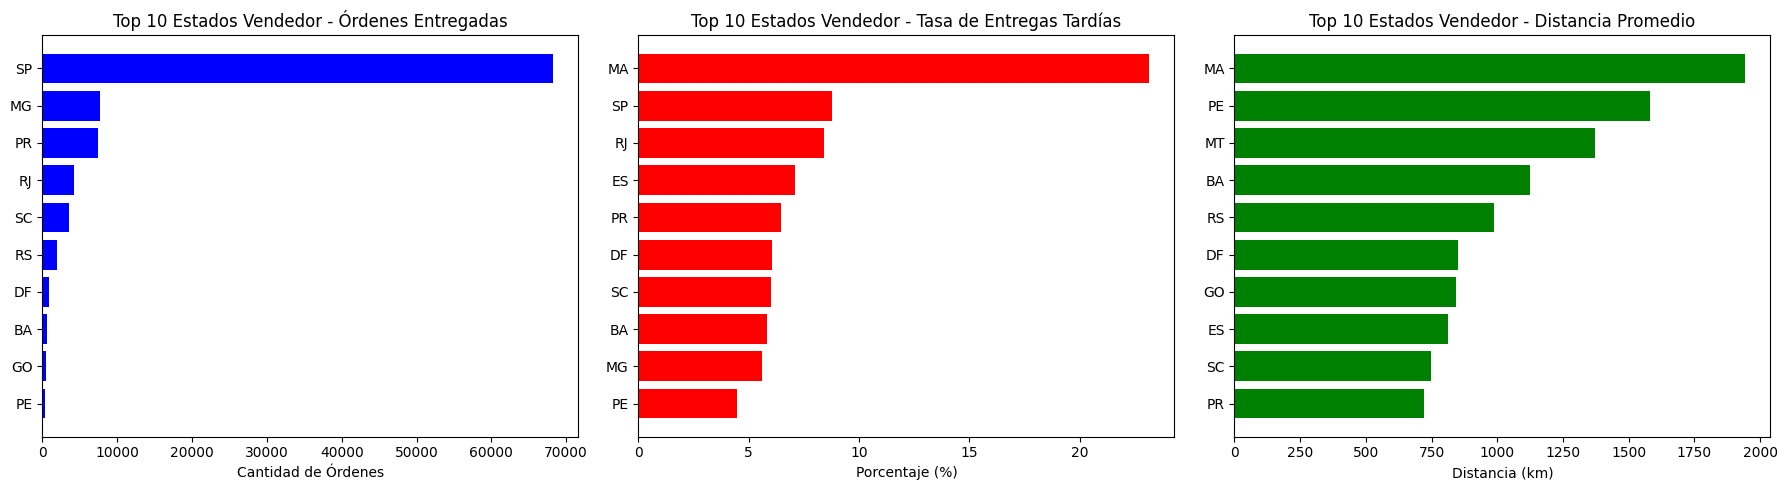

In [32]:
# Visualizaciones por estado vendedor
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top estados vendedor por órdenes entregadas
top_seller_orders = logistics_seller_state_filtered.nlargest(10, 'delivered_orders')
axes[0].barh(top_seller_orders['main_seller_state'], top_seller_orders['delivered_orders'], color='blue')
axes[0].set_title('Top 10 Estados Vendedor - Órdenes Entregadas')
axes[0].set_xlabel('Cantidad de Órdenes')
axes[0].invert_yaxis()

# Estados vendedor con mayor late_delivery_rate
top_seller_late = logistics_seller_state_filtered.nlargest(10, 'late_delivery_rate')
axes[1].barh(top_seller_late['main_seller_state'], top_seller_late['late_delivery_rate'], color='red')
axes[1].set_title('Top 10 Estados Vendedor - Tasa de Entregas Tardías')
axes[1].set_xlabel('Porcentaje (%)')
axes[1].invert_yaxis()

# Estados vendedor con mayor distancia promedio
top_seller_distance = logistics_seller_state_filtered.nlargest(10, 'avg_distance_km')
axes[2].barh(top_seller_distance['main_seller_state'], top_seller_distance['avg_distance_km'], color='green')
axes[2].set_title('Top 10 Estados Vendedor - Distancia Promedio')
axes[2].set_xlabel('Distancia (km)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'logistics_by_seller_state.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Impacto logístico en satisfacción

In [35]:
# Crear comparaciones de satisfacción

# Evitar warnings si logistics_base viene filtrado de otro DataFrame
logistics_base = logistics_base.copy()

# Asegurar que is_late quede como 0/1
logistics_base['is_late'] = logistics_base['is_late'].astype(int)

# 1. Review promedio entre órdenes tardías y no tardías
review_by_late = logistics_base.groupby('is_late')['review_score_avg'].mean()

# 2. Bad review rate entre órdenes tardías y no tardías
bad_review_by_late = logistics_base.groupby('is_late')['bad_review'].mean() * 100

# 3. Delivery_time_days promedio por review_score_avg redondeado
logistics_base['review_score_rounded'] = logistics_base['review_score_avg'].round()

delivery_time_by_review = (
    logistics_base
    .groupby('review_score_rounded')['delivery_time_days']
    .mean()
)

# 4. Delivery_delay_days promedio por review_score_avg redondeado
delay_by_review = (
    logistics_base
    .groupby('review_score_rounded')['delivery_delay_days']
    .mean()
)

# Crear lista de resultados
rows = [
    {
        'metric': 'avg_review_late_orders',
        'value': review_by_late.get(1, None)
    },
    {
        'metric': 'avg_review_on_time_orders',
        'value': review_by_late.get(0, None)
    },
    {
        'metric': 'bad_review_rate_late_orders',
        'value': bad_review_by_late.get(1, None)
    },
    {
        'metric': 'bad_review_rate_on_time_orders',
        'value': bad_review_by_late.get(0, None)
    }
]

# Agregar métricas por review score
review_scores = (
    logistics_base['review_score_rounded']
    .dropna()
    .sort_values()
    .unique()
)

for score in review_scores:
    rows.append({
        'metric': f'delivery_time_review_score_{int(score)}',
        'value': delivery_time_by_review.get(score, None)
    })

    rows.append({
        'metric': f'delivery_delay_review_score_{int(score)}',
        'value': delay_by_review.get(score, None)
    })

# Crear tabla logistics_satisfaction_impact
logistics_satisfaction_impact = pd.DataFrame(rows)

# Guardar en reports
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
logistics_satisfaction_impact.to_csv(
    REPORTS_DIR / 'logistics_satisfaction_impact.csv',
    index=False
)

print("Impacto logístico en satisfacción:")
display(logistics_satisfaction_impact)

Impacto logístico en satisfacción:


,metric,value
0,avg_review_late_orders,2.566562
1,avg_review_on_time_orders,4.294151
2,bad_review_rate_late_orders,60.966981
3,bad_review_rate_on_time_orders,9.995560
4,delivery_time_review_score_1,21.339995
5,delivery_delay_review_score_1,-3.336156
6,delivery_time_review_score_2,16.686322
7,delivery_delay_review_score_2,-7.920144
8,delivery_time_review_score_3,14.247096
9,delivery_delay_review_score_3,-10.084795


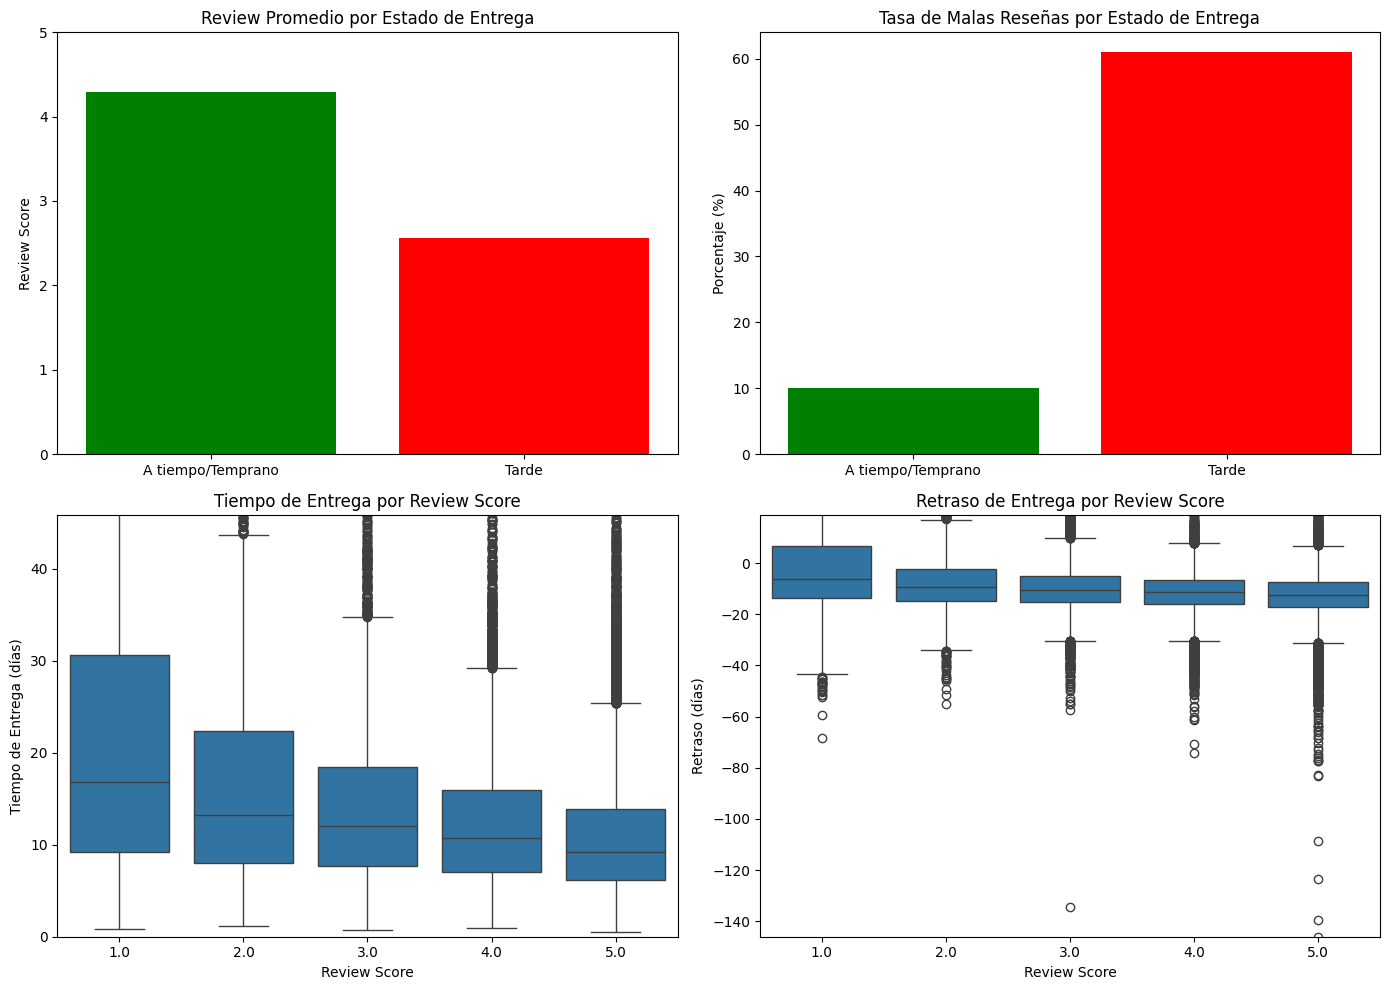

In [36]:
# Visualizaciones de impacto en satisfacción
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Barras de review promedio según is_late
late_labels = ['A tiempo/Temprano', 'Tarde']
review_values = [review_by_late[0] if 0 in review_by_late.index else 0, 
                 review_by_late[1] if 1 in review_by_late.index else 0]
axes[0, 0].bar(late_labels, review_values, color=['green', 'red'])
axes[0, 0].set_title('Review Promedio por Estado de Entrega')
axes[0, 0].set_ylabel('Review Score')
axes[0, 0].set_ylim(0, 5)

# Barras de bad_review_rate según is_late
bad_review_values = [bad_review_by_late[0] if 0 in bad_review_by_late.index else 0,
                     bad_review_by_late[1] if 1 in bad_review_by_late.index else 0]
axes[0, 1].bar(late_labels, bad_review_values, color=['green', 'red'])
axes[0, 1].set_title('Tasa de Malas Reseñas por Estado de Entrega')
axes[0, 1].set_ylabel('Porcentaje (%)')

# Boxplot de delivery_time_days por review_score redondeado
logistics_base_viz = logistics_base[logistics_base['review_score_rounded'].notna()]
sns.boxplot(data=logistics_base_viz, x='review_score_rounded', y='delivery_time_days', ax=axes[1, 0])
axes[1, 0].set_title('Tiempo de Entrega por Review Score')
axes[1, 0].set_xlabel('Review Score')
axes[1, 0].set_ylabel('Tiempo de Entrega (días)')
axes[1, 0].set_ylim(0, logistics_base_viz['delivery_time_days'].quantile(0.99))

# Boxplot de delivery_delay_days por review_score redondeado
sns.boxplot(data=logistics_base_viz, x='review_score_rounded', y='delivery_delay_days', ax=axes[1, 1])
axes[1, 1].set_title('Retraso de Entrega por Review Score')
axes[1, 1].set_xlabel('Review Score')
axes[1, 1].set_ylabel('Retraso (días)')
delay_min = logistics_base_viz['delivery_delay_days'].min()
delay_max = logistics_base_viz['delivery_delay_days'].quantile(0.99)
axes[1, 1].set_ylim(delay_min, delay_max)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'logistics_satisfaction_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 18. Valores extremos logísticos

In [37]:
# Identificar outliers usando percentiles 1 y 99
# delivery_time_days
delivery_time_p1 = logistics_base['delivery_time_days'].quantile(0.01)
delivery_time_p99 = logistics_base['delivery_time_days'].quantile(0.99)
# delivery_delay_days
delay_p1 = logistics_base['delivery_delay_days'].quantile(0.01)
delay_p99 = logistics_base['delivery_delay_days'].quantile(0.99)
# total_freight
freight_p1 = logistics_base['total_freight'].quantile(0.01)
freight_p99 = logistics_base['total_freight'].quantile(0.99)

# Crear tabla logistics_extreme_values
logistics_extreme_values = pd.DataFrame({
    'metric': ['delivery_time_p1', 'delivery_time_p99', 'delivery_delay_p1', 'delivery_delay_p99',
               'freight_p1', 'freight_p99'],
    'value': [delivery_time_p1, delivery_time_p99, delay_p1, delay_p99, freight_p1, freight_p99]
})

# Guardar en reports
logistics_extreme_values.to_csv(REPORTS_DIR / 'logistics_extreme_values.csv', index=False)

print("Valores extremos logísticos:")
display(logistics_extreme_values)

Valores extremos logísticos:


,metric,value
0,delivery_time_p1,1.825203
1,delivery_time_p99,46.049913
2,delivery_delay_p1,-35.154239
3,delivery_delay_p99,18.939306
4,freight_p1,7.390000
5,freight_p99,104.245000


In [38]:
# Filtrar outliers para análisis
logistics_no_outliers = logistics_base[
    (logistics_base['delivery_time_days'] >= delivery_time_p1) & 
    (logistics_base['delivery_time_days'] <= delivery_time_p99) &
    (logistics_base['delivery_delay_days'] >= delay_p1) & 
    (logistics_base['delivery_delay_days'] <= delay_p99) &
    (logistics_base['total_freight'] >= freight_p1) & 
    (logistics_base['total_freight'] <= freight_p99)
].copy()

print(f"Filas originales: {len(logistics_base):,}")
print(f"Filas sin outliers: {len(logistics_no_outliers):,}")
print(f"Filas eliminadas: {len(logistics_base) - len(logistics_no_outliers):,} ({(len(logistics_base) - len(logistics_no_outliers)) / len(logistics_base) * 100:.2f}%)")

Filas originales: 96,476
Filas sin outliers: 92,066
Filas eliminadas: 4,410 (4.57%)


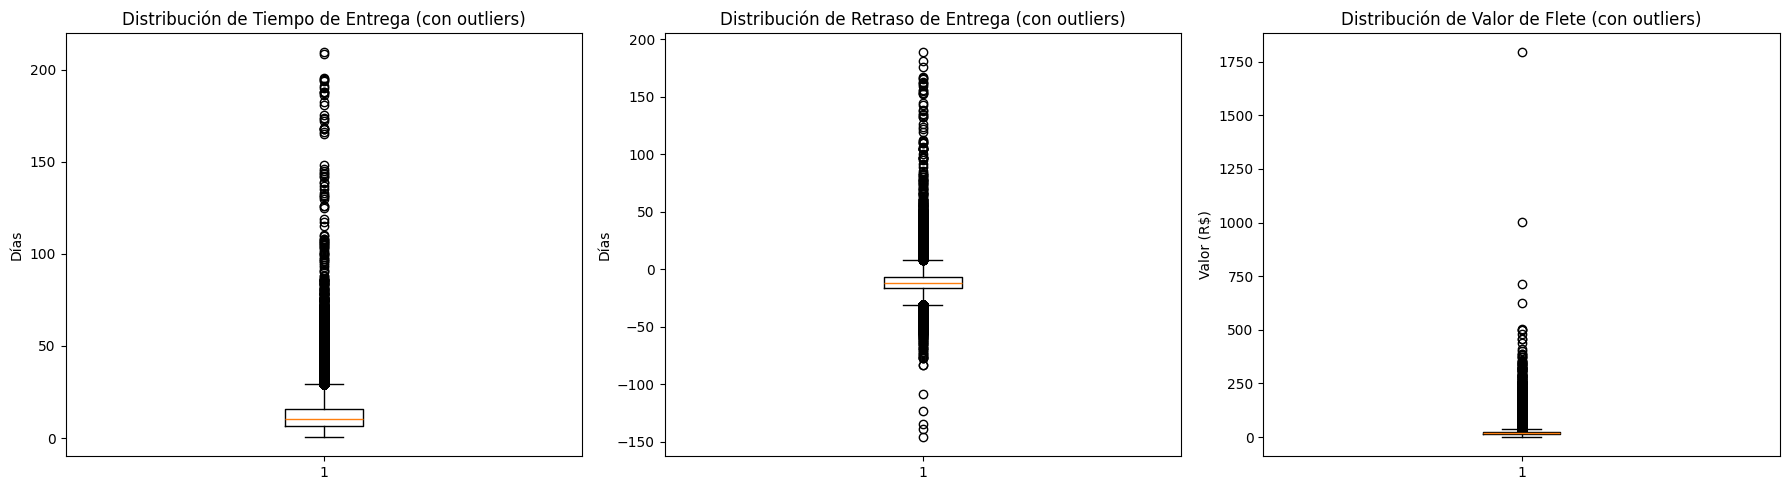

In [39]:
# Visualizaciones de outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot de delivery_time_days
axes[0].boxplot(logistics_base['delivery_time_days'].dropna())
axes[0].set_title('Distribución de Tiempo de Entrega (con outliers)')
axes[0].set_ylabel('Días')

# Boxplot de delivery_delay_days
axes[1].boxplot(logistics_base['delivery_delay_days'].dropna())
axes[1].set_title('Distribución de Retraso de Entrega (con outliers)')
axes[1].set_ylabel('Días')

# Boxplot de total_freight
axes[2].boxplot(logistics_base['total_freight'].dropna())
axes[2].set_title('Distribución de Valor de Flete (con outliers)')
axes[2].set_ylabel('Valor (R$)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'logistics_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

## 19. Conclusiones ejecutivas

In [41]:
# ============================================================
# CONCLUSIONES EJECUTIVAS - ANÁLISIS LOGÍSTICO
# ============================================================

def get_top_values(df, metric_col, label_candidates, n=3):
    """
    Retorna los top n valores de una columna de etiqueta,
    ordenados por una métrica. Soporta etiquetas como columna o índice.
    """

    temp = df.copy()

    # Si la etiqueta está en el índice, convertir índice a columna
    if temp.index.name is not None:
        temp = temp.reset_index()

    # Buscar columna de etiqueta disponible
    label_col = None
    for col in label_candidates:
        if col in temp.columns:
            label_col = col
            break

    if label_col is None:
        return "No disponible"

    if metric_col not in temp.columns:
        return "No disponible"

    result = (
        temp
        .dropna(subset=[label_col, metric_col])
        .nlargest(n, metric_col)[label_col]
        .astype(str)
        .tolist()
    )

    return ", ".join(result) if result else "No disponible"


# Tops por estado
top_late_states = get_top_values(
    logistics_by_state,
    metric_col='late_delivery_rate',
    label_candidates=['customer_state', 'state']
)

top_time_states = get_top_values(
    logistics_by_state,
    metric_col='avg_delivery_time_days',
    label_candidates=['customer_state', 'state']
)

# Tops por categoría
top_late_categories = get_top_values(
    logistics_by_category,
    metric_col='late_delivery_rate',
    label_candidates=[
        'product_category_name',
        'product_category_name_english',
        'category',
        'main_category'
    ]
)

top_time_categories = get_top_values(
    logistics_by_category,
    metric_col='avg_delivery_time_days',
    label_candidates=[
        'product_category_name',
        'product_category_name_english',
        'category',
        'main_category'
    ]
)

# Tops por estado vendedor según distancia
top_seller_distance = get_top_values(
    logistics_seller_state_filtered,
    metric_col='avg_distance_km',
    label_candidates=['main_seller_state', 'seller_state', 'state']
)

# Valores de satisfacción
review_late = review_by_late.get(1, review_by_late.get(True, 0))
review_ontime = review_by_late.get(0, review_by_late.get(False, 0))

bad_review_late = bad_review_by_late.get(1, bad_review_by_late.get(True, 0))
bad_review_ontime = bad_review_by_late.get(0, bad_review_by_late.get(False, 0))


print("""
## CONCLUSIONES EJECUTIVAS - ANÁLISIS LOGÍSTICO

### 1. KPIs Generales
- Tasa de entregas tardías: {late_rate:.2f}%
- Tiempo promedio de entrega: {avg_delivery:.2f} días
- Retraso promedio: {avg_delay:.2f} días
- Review promedio: {avg_review:.2f}/5
- Tasa de malas reseñas: {bad_review_rate:.2f}%

### 2. Distribución de Tiempos
- P25: {p25:.2f} días
- P50 (mediana): {p50:.2f} días
- P75: {p75:.2f} días
- P90: {p90:.2f} días

### 3. Cumplimiento de Promesas
- Porcentaje de entregas dentro de la fecha prometida: {on_time_rate:.2f}%

### 4. Análisis por Estado
- Estados con mayor tasa de entregas tardías: {top_late_states}
- Estados con mayor tiempo de entrega: {top_time_states}

### 5. Análisis por Categoría
- Categorías con mayor tasa de entregas tardías: {top_late_categories}
- Categorías con mayor tiempo de entrega: {top_time_categories}

### 6. Impacto de la Distancia
- Mayor distancia se correlaciona con: {distance_impact}
- Estados vendedor con mayor distancia promedio: {top_seller_distance}

### 7. Impacto en Satisfacción
- Review promedio en entregas tardías: {review_late:.2f}/5
- Review promedio en entregas a tiempo: {review_ontime:.2f}/5
- Tasa de malas reseñas en entregas tardías: {bad_review_late:.2f}%
- Tasa de malas reseñas en entregas a tiempo: {bad_review_ontime:.2f}%

### 8. Recomendaciones
1. Priorizar mejoras logísticas en estados con mayor tasa de entregas tardías.
2. Revisar promesas de entrega en categorías con mayor retraso.
3. Implementar alertas tempranas para órdenes con riesgo de retraso.
4. Optimizar rutas para reducir tiempos de entrega en distancias largas.
5. Establecer SLAs específicos por categoría y estado.
""".format(
    late_rate=logistics_base['is_late'].mean() * 100,
    avg_delivery=logistics_base['delivery_time_days'].mean(),
    avg_delay=logistics_base['delivery_delay_days'].mean(),
    avg_review=logistics_base['review_score_avg'].mean(),
    bad_review_rate=logistics_base['bad_review'].mean() * 100,

    p25=logistics_base['delivery_time_days'].quantile(0.25),
    p50=logistics_base['delivery_time_days'].median(),
    p75=logistics_base['delivery_time_days'].quantile(0.75),
    p90=logistics_base['delivery_time_days'].quantile(0.90),

    on_time_rate=(1 - logistics_base['is_late'].mean()) * 100,

    top_late_states=top_late_states,
    top_time_states=top_time_states,
    top_late_categories=top_late_categories,
    top_time_categories=top_time_categories,

    distance_impact="mayor tiempo de entrega y mayor valor de flete",
    top_seller_distance=top_seller_distance,

    review_late=review_late,
    review_ontime=review_ontime,
    bad_review_late=bad_review_late,
    bad_review_ontime=bad_review_ontime
))


## CONCLUSIONES EJECUTIVAS - ANÁLISIS LOGÍSTICO

### 1. KPIs Generales
- Tasa de entregas tardías: 8.11%
- Tiempo promedio de entrega: 12.56 días
- Retraso promedio: -11.18 días
- Review promedio: 4.16/5
- Tasa de malas reseñas: 13.93%

### 2. Distribución de Tiempos
- P25: 6.77 días
- P50 (mediana): 10.22 días
- P75: 15.72 días
- P90: 23.10 días

### 3. Cumplimiento de Promesas
- Porcentaje de entregas dentro de la fecha prometida: 91.89%

### 4. Análisis por Estado
- Estados con mayor tasa de entregas tardías: AL, MA, PI
- Estados con mayor tiempo de entrega: RR, AP, AM

### 5. Análisis por Categoría
- Categorías con mayor tasa de entregas tardías: home_comfort_2, furniture_mattress_and_upholstery, audio
- Categorías con mayor tiempo de entrega: office_furniture, fashion_shoes, christmas_supplies

### 6. Impacto de la Distancia
- Mayor distancia se correlaciona con: mayor tiempo de entrega y mayor valor de flete
- Estados vendedor con mayor distancia promedio: MA, PE, MT

### 7. Imp